In [68]:
import pandas as pd
import numpy as np

In [69]:
crimes = pd.read_csv('C:/Hackathon CDMX/conciencia_backend/analytics/Data/Crimes/carpetasFGJ_2024.csv')
print(crimes.shape)
crimes.head()

(138630, 21)


,anio_inicio,mes_inicio,fecha_inicio,hora_inicio,anio_hecho,mes_hecho,fecha_hecho,hora_hecho,delito,categoria_delito,...,fiscalia,agencia,unidad_investigacion,colonia_hecho,colonia_catalogo,alcaldia_hecho,alcaldia_catalogo,municipio_hecho,latitud,longitud
0,2024,Enero,2024-01-01,00:20:00,2024.0,Enero,2024-01-01,00:20:00,PERDIDA DE LA VIDA POR OTRAS CAUSAS,HECHO NO DELICTIVO,...,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN TLALPAN,UAT-TLP-3,UI-1SD,SAN MIGUEL TOPILEJO,Pueblo San Miguel Topilejo,TLALPAN,Tlalpan,CDMX,19.198611,-99.140064
1,2024,Enero,2024-01-01,01:12:00,2023.0,Diciembre,2023-12-28,21:45:00,HOMICIDIO CULPOSO POR TRÁNSITO VEHICULAR (COLI...,DELITO DE BAJO IMPACTO,...,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN AZCAP...,UAT-AZ-4,UI-2SD,AERONÁUTICA MILITAR,Aeronautica Militar,VENUSTIANO CARRANZA,Venustiano Carranza,CDMX,19.420629,-99.115402
2,2024,Enero,2024-01-01,01:14:00,2023.0,Diciembre,2023-12-31,23:00:00,PERDIDA DE LA VIDA POR CAIDA,HECHO NO DELICTIVO,...,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN IZTAP...,UAT-IZP-5,1 SIN DETENIDO,OJITO DE AGUA,Pueblo Santa Maria Aztahuacan,IZTAPALAPA,Iztapalapa,CDMX,19.347257,-99.024526
3,2024,Enero,2024-01-01,02:29:00,2023.0,Diciembre,2023-12-31,23:50:00,"ROBO EN EVENTOS MASIVOS (DEPORTIVOS, CULTURALE...",DELITO DE BAJO IMPACTO,...,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN CUAUH...,UAT-CUH-6,UI-1SD,CENTRO,Centro,CUAUHTEMOC,Cuauhtémoc,CDMX,19.434052,-99.134837
4,2024,Enero,2024-01-01,03:26:00,2024.0,Enero,2024-01-01,02:10:00,PERDIDA DE LA VIDA POR PARO CARDIACO,HECHO NO DELICTIVO,...,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN MAGDA...,UAT-MC-2,UI-1SD,LOMAS DE SAN BERNABÉ,Lomas De San Bernabe,LA MAGDALENA CONTRERAS,La Magdalena Contreras,CDMX,19.314159,-99.263989


# PREPROCESAMIENTO Y EDA

In [70]:
df_crimes = crimes[(crimes['alcaldia_hecho']=='TLALPAN') & (crimes['alcaldia_catalogo']=='Tlalpan') & (crimes['competencia']=='FUERO COMUN')]

print(df_crimes.shape)
df_crimes.head()


(8670, 21)


,anio_inicio,mes_inicio,fecha_inicio,hora_inicio,anio_hecho,mes_hecho,fecha_hecho,hora_hecho,delito,categoria_delito,...,fiscalia,agencia,unidad_investigacion,colonia_hecho,colonia_catalogo,alcaldia_hecho,alcaldia_catalogo,municipio_hecho,latitud,longitud
17,2024,Enero,2024-01-01,09:34:00,2024.0,Enero,2024-01-01,08:20:00,ROBO A NEGOCIO SIN VIOLENCIA POR FARDEROS (TIE...,DELITO DE BAJO IMPACTO,...,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN TLALPAN,TLP-3,UI-3CD,TLALPAN CENTRO I,Tlalpan,TLALPAN,Tlalpan,CDMX,19.294918,-99.175004
33,2024,Enero,2024-01-01,11:41:00,2024.0,Enero,2024-01-01,08:00:00,AMENAZAS,DELITO DE BAJO IMPACTO,...,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN TLALPAN,UAT-TLP-5,UI-1SD,SAN MIGUEL AJUSCO,El Charco,TLALPAN,Tlalpan,CDMX,19.232057,-99.213163
38,2024,Enero,2024-01-01,12:26:00,2024.0,Enero,2024-01-01,02:00:00,ROBO DE VEHICULO DE SERVICIO PARTICULAR SIN VI...,ROBO DE VEHÍCULO CON Y SIN VIOLENCIA,...,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN TLALPAN,UAT-TLP-1,UI-1SD,HÉROES DE PADIERNA,Heroes De Padierna,TLALPAN,Tlalpan,CDMX,19.279583,-99.217773
46,2024,Enero,2024-01-01,12:50:00,2023.0,Diciembre,2023-12-26,19:00:00,AMENAZAS,DELITO DE BAJO IMPACTO,...,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN TLALPAN,UAT-TLP-3,UI-1SD,SANTA ÚRSULA XITLA,Pueblo Santa Ursula Xitla,TLALPAN,Tlalpan,CDMX,19.280928,-99.179631
57,2024,Enero,2024-01-01,13:58:00,2023.0,Noviembre,2023-11-08,17:00:00,AMENAZAS,DELITO DE BAJO IMPACTO,...,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN TLALPAN,UAT-TLP-3,UI-1SD,SANTA ÚRSULA XITLA,Fuentes Brotantes,TLALPAN,Tlalpan,CDMX,19.280611,-99.182588


In [71]:
# Crear un DataFrame con el conteo y el porcentaje de nulos
missing_data = pd.DataFrame({
    'Nulos': df_crimes.isnull().sum(),
    'Porcentaje': (df_crimes.isnull().mean() * 100).round(2)
})

# Filtrar solo las columnas que tienen al menos un valor nulo
missing_data = missing_data[missing_data['Nulos'] > 0].sort_values(by='Nulos', ascending=False)

print(missing_data)

                      Nulos  Porcentaje
colonia_catalogo        387        4.46
hora_hecho               16        0.18
unidad_investigacion     15        0.17
hora_inicio               1        0.01


> Mejor practica:
> * `hora_inicio`,`hora_hecho`: Eliminar
> * `unidad_investigacion`: Rellenar con la moda
> * `colonia_catalogo`: Rellenar con `Desconocido`

In [72]:
# Eliminar datos
df_crimes = df_crimes.dropna(subset=['hora_inicio','hora_hecho'])

# tipo_entrada
df_crimes['unidad_investigacion'] = df_crimes['unidad_investigacion'].fillna(df_crimes['unidad_investigacion'].mode()[0])

# colonia_catalogo
df_crimes['colonia_catalogo'] = df_crimes['colonia_catalogo'].fillna('Desconocido')

In [73]:
df_crimes.info()

<class 'pandas.DataFrame'>
Index: 8653 entries, 17 to 138589
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   anio_inicio           8653 non-null   int64  
 1   mes_inicio            8653 non-null   str    
 2   fecha_inicio          8653 non-null   str    
 3   hora_inicio           8653 non-null   str    
 4   anio_hecho            8653 non-null   float64
 5   mes_hecho             8653 non-null   str    
 6   fecha_hecho           8653 non-null   str    
 7   hora_hecho            8653 non-null   str    
 8   delito                8653 non-null   str    
 9   categoria_delito      8653 non-null   str    
 10  competencia           8653 non-null   str    
 11  fiscalia              8653 non-null   str    
 12  agencia               8653 non-null   str    
 13  unidad_investigacion  8653 non-null   str    
 14  colonia_hecho         8653 non-null   str    
 15  colonia_catalogo      8653 non-nul

> Se eliminan columnas que como
> * datos de creacion del folio (lo importante es como termina): `anio_inicio`, `mes_inicio`, `fecha_inicio`
> * columnas con un solo valor: `alcaldia_hecho`, `alcaldia_catalogo`

In [74]:
df_crimes.drop(inplace=True, columns=['anio_inicio', 'mes_inicio', 'fecha_inicio','hora_inicio', 'alcaldia_hecho','alcaldia_catalogo','municipio_hecho','delito','competencia'])

In [75]:
mapeo_meses = {
    'Enero': 1, 'Febrero': 2, 'Marzo': 3, 'Abril': 4,
    'Mayo': 5, 'Junio': 6, 'Julio': 7, 'Agosto': 8,
    'Septiembre': 9, 'Octubre': 10, 'Noviembre': 11, 'Diciembre': 12
}

# Aplicamos el mapeo a la columna
df_crimes['mes_numerico'] = df_crimes['mes_hecho'].map(mapeo_meses)

In [76]:

# Convertir fecha_cierre de string a formato fecha (datetime)
df_crimes['fecha_hecho'] = pd.to_datetime(df_crimes['fecha_hecho'], format='%Y-%m-%d')

# Convertir hora_cierre a datetime PRIMERO (para poder usar .dt)
df_crimes['hora_hecho_dt'] = pd.to_datetime(df_crimes['hora_hecho'], format='%H:%M:%S')

# Extraer la hora ANTES de convertir a time
df_crimes['hora'] = df_crimes['hora_hecho_dt'].dt.hour

# AHORA convertir hora_cierre a tipo time (si lo necesitas)
df_crimes['hora_hecho'] = df_crimes['hora_hecho_dt'].dt.time

# Eliminar columna temporal si no la necesitas
df_crimes = df_crimes.drop(columns=['hora_hecho_dt'])

# Hacer enteros
df_crimes['anio_hecho'] = df_crimes['anio_hecho'].astype(int)
df_crimes['mes_numerico'] = df_crimes['mes_numerico'].astype(int)
df_crimes['hora'] = df_crimes['hora'].astype(int)



In [77]:
df_crimes.info()
df_crimes.head(1)

<class 'pandas.DataFrame'>
Index: 8653 entries, 17 to 138589
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   anio_hecho            8653 non-null   int64         
 1   mes_hecho             8653 non-null   str           
 2   fecha_hecho           8653 non-null   datetime64[us]
 3   hora_hecho            8653 non-null   object        
 4   categoria_delito      8653 non-null   str           
 5   fiscalia              8653 non-null   str           
 6   agencia               8653 non-null   str           
 7   unidad_investigacion  8653 non-null   str           
 8   colonia_hecho         8653 non-null   str           
 9   colonia_catalogo      8653 non-null   str           
 10  latitud               8653 non-null   float64       
 11  longitud              8653 non-null   float64       
 12  mes_numerico          8653 non-null   int64         
 13  hora                  8653 non-

,anio_hecho,mes_hecho,fecha_hecho,hora_hecho,categoria_delito,fiscalia,agencia,unidad_investigacion,colonia_hecho,colonia_catalogo,latitud,longitud,mes_numerico,hora
17,2024,Enero,2024-01-01,08:20:00,DELITO DE BAJO IMPACTO,FISCALÍA DE INVESTIGACIÓN TERRITORIAL EN TLALPAN,TLP-3,UI-3CD,TLALPAN CENTRO I,Tlalpan,19.294918,-99.175004,1,8


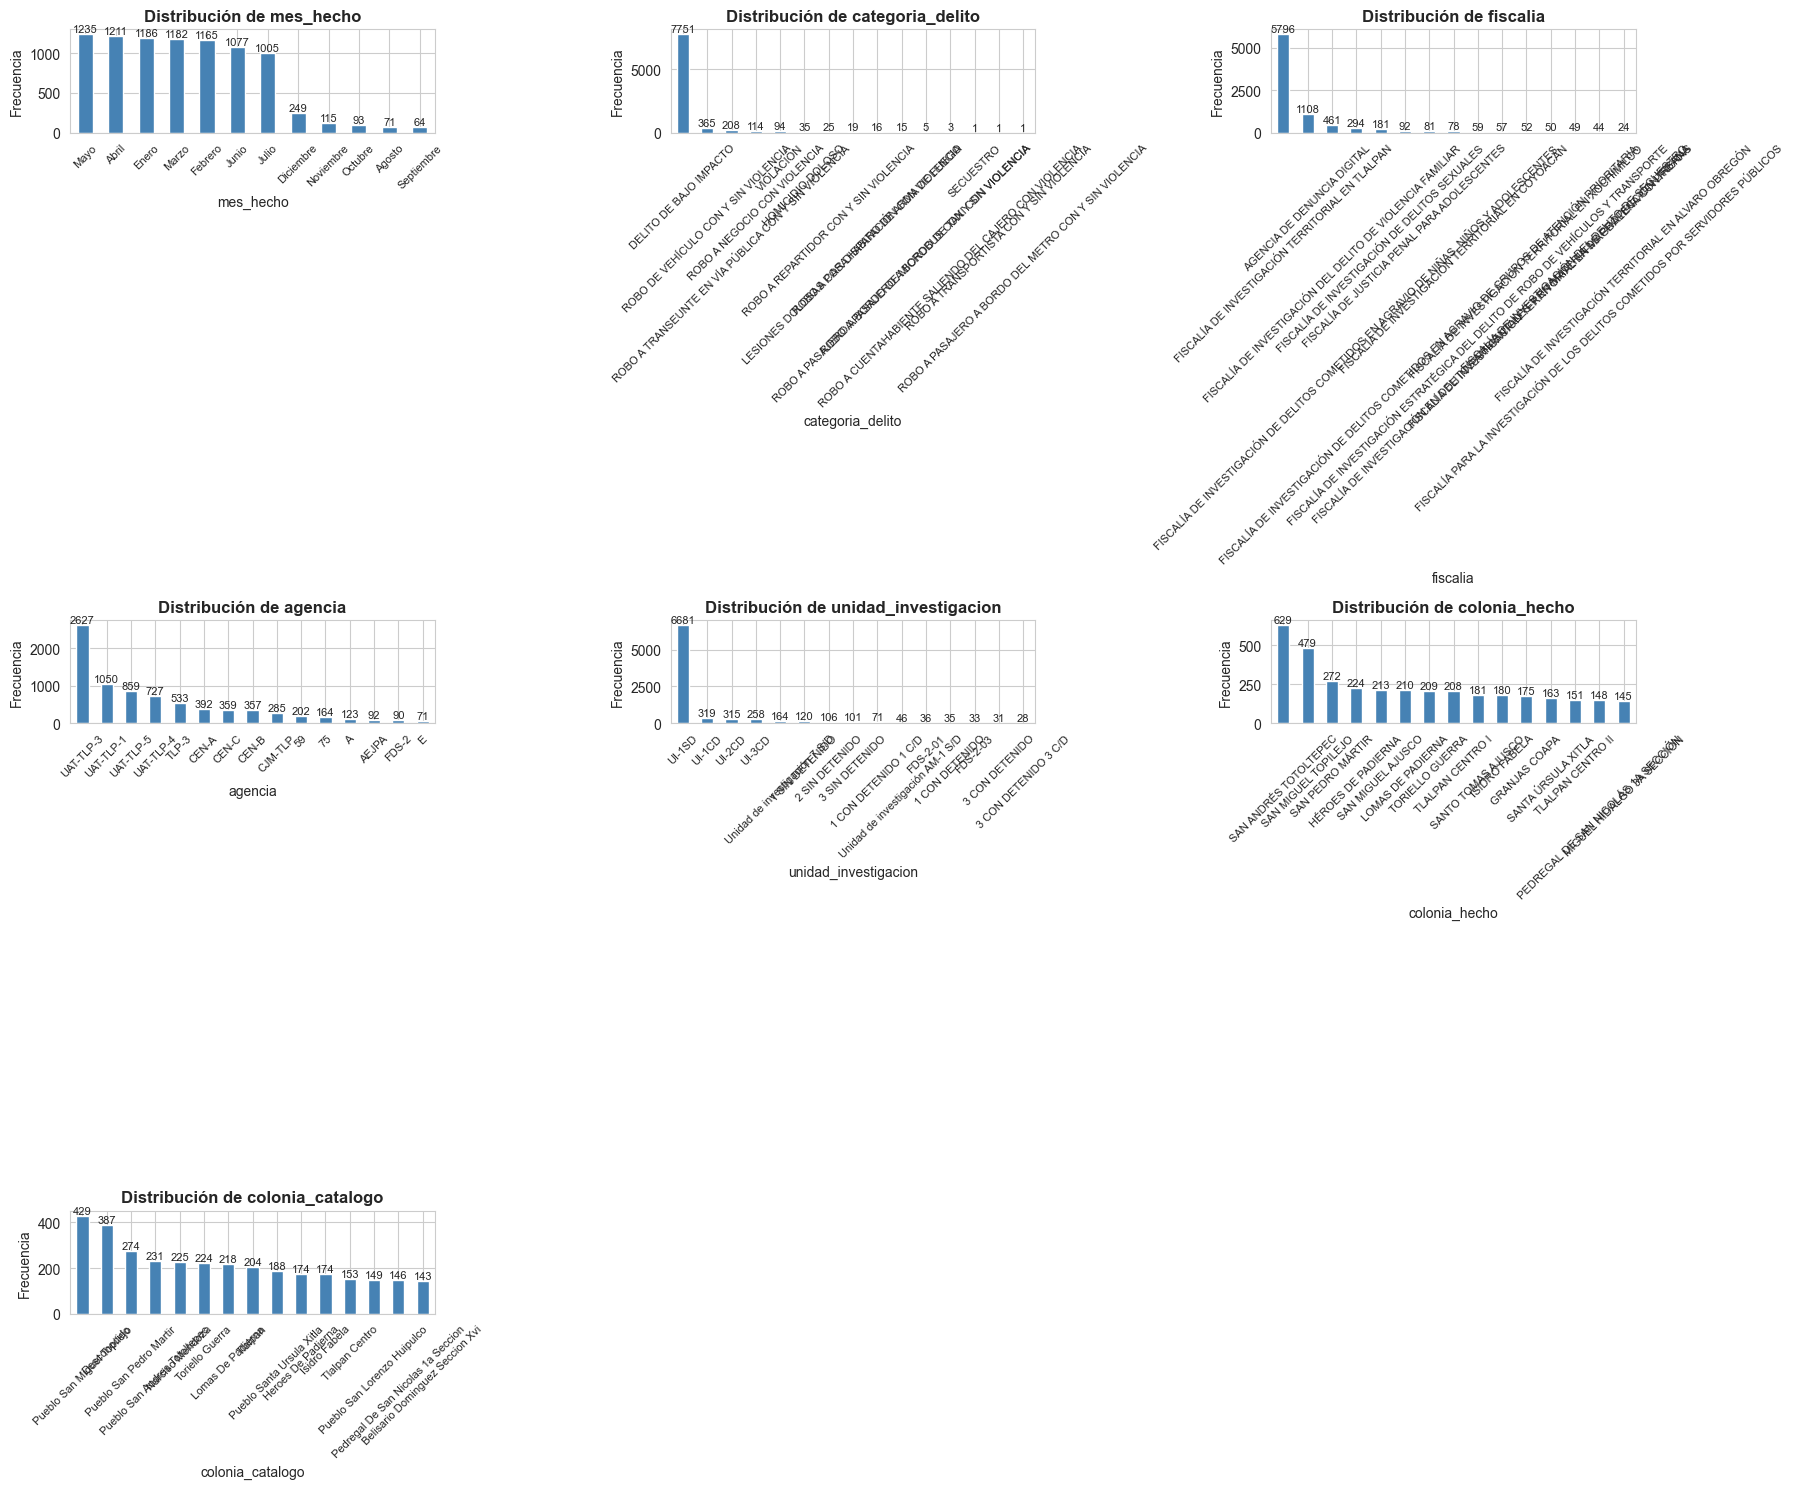


Total de variables categóricas: 7
Variables: mes_hecho, categoria_delito, fiscalia, agencia, unidad_investigacion, colonia_hecho, colonia_catalogo


In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identificar columnas categóricas (tipo object/string)
categorical_cols = df_crimes.select_dtypes(include=['str']).columns.tolist()

# Configurar el estilo
sns.set_style("whitegrid")

# Crear gráficos de barras para cada variable categórica
n_cols = len(categorical_cols)
n_rows = (n_cols + 2) // 3  # 3 gráficos por fila

fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5*n_rows))
axes = axes.flatten() if n_cols > 1 else [axes]

for idx, col in enumerate(categorical_cols):
    # Contar valores y tomar los top 15 (para evitar gráficos muy saturados)
    value_counts = df_crimes[col].value_counts().head(15)
    
    # Crear gráfico de barras
    ax = axes[idx]
    value_counts.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    
    # Añadir valores en las barras
    for i, v in enumerate(value_counts):
        ax.text(i, v, str(v), ha='center', va='bottom', fontsize=8)

# Ocultar ejes vacíos si hay menos gráficos que subplots
for idx in range(n_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

# Mostrar resumen de variables categóricas
print(f"\nTotal de variables categóricas: {n_cols}")
print(f"Variables: {', '.join(categorical_cols)}")


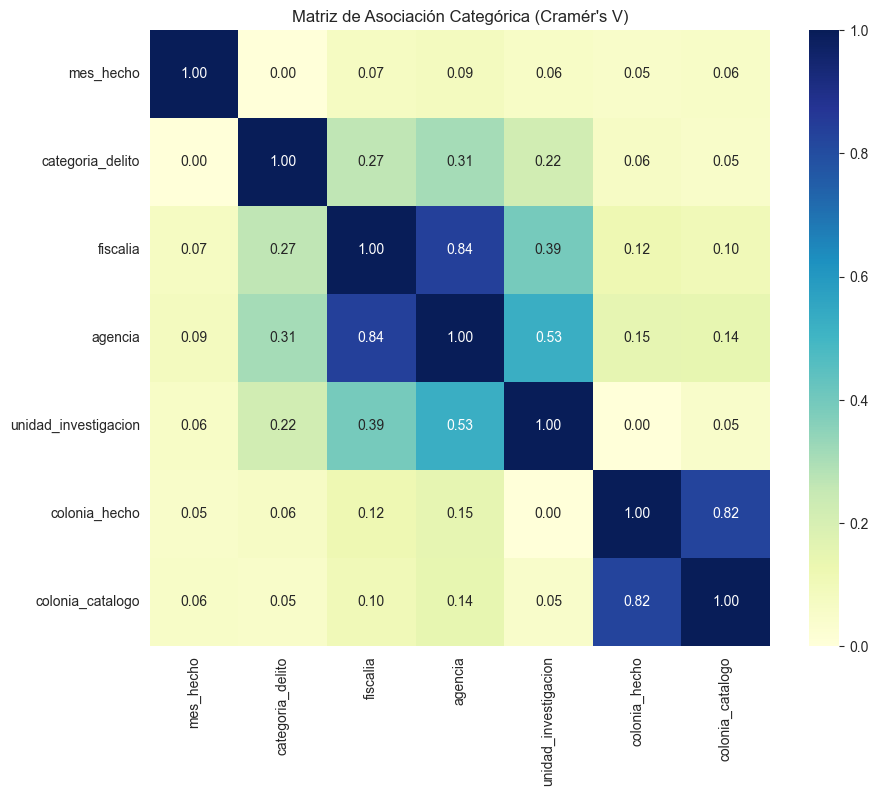

In [79]:
from scipy.stats import chi2_contingency

# 1. Función para Cramér's V (Asociación Categórica)
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 2. Matriz de Asociación Categórica (Cramér's V)
if len(categorical_cols) > 1:
    v_results = []
    for col1 in categorical_cols:
        row = []
        for col2 in categorical_cols:
            row.append(cramers_v(df_crimes[col1], df_crimes[col2]))
        v_results.append(row)
    
    v_matrix = pd.DataFrame(v_results, index=categorical_cols, columns=categorical_cols)

    plt.figure(figsize=(10, 8))
    sns.heatmap(v_matrix, annot=True, cmap='YlGnBu', fmt=".2f", vmin=0, vmax=1)
    plt.title("Matriz de Asociación Categórica (Cramér's V)")
    plt.show()

In [80]:
# Si tienes un DataFrame con columnas 'latitud' y 'longitud'
df_crimes['lat_anon'] = df_crimes['latitud'].apply(lambda x: np.round(x, 3))
df_crimes['lon_anon'] = df_crimes['longitud'].apply(lambda x: np.round(x, 3))

# CREACION NUEVO DF

In [81]:
df_crimes.to_csv('C:/Hackathon CDMX/conciencia_backend/analytics/clean_data/delitos.csv', index=False)
